In [1]:
!pip install mapie

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.6/555.6 kB 5.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from mapie.regression import SplitConformalRegressor

In [3]:
df = pd.read_csv("/kaggle/input/notebooks/madisrinija/02-feature-engineering-ipynb/student_performance_dataset_cleaned.csv")
df.shape

(1000, 19)

In [4]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,at_risk,academic_level,attendance_risk_level,sleep_deviation,deviation_bin,high_workload_low_sleep,engagement_score
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A,0,excellent,Healthy,1.0,1.0,0,0.805426
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A,0,excellent,Healthy,1.8,2.0,1,0.921053
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A,0,excellent,Healthy,0.4,0.0,0,0.417909
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B,0,excellent,Healthy,0.5,0.0,0,0.592843
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D,1,average,Healthy,2.9,3.0,1,0.331199


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
 12  at_risk                     1000 non-null   int64  
 13  academic_level              1000 n

Models

* Linear Regression — baseline
* Random Forest Regressor — non-linear benchmark
* XGBoost Regressor — advanced model


| Metric   | Purpose                                       |
| -------- | --------------------------------------------- |
| **MAE**  | Average prediction error in exam-score points |
| RMSE     | Penalizes larger prediction errors            |
| R² Score | Measures explained variance                   |


Primary Metric: MAE

Prioritize MAE because it is easiest to communicate.

#### Recommended Model Selection

Select the best model primarily based on:

* Lowest MAE
* Lowest RMSE
* Highest R²


In [6]:
results = pd.DataFrame(columns=[
    'Model', 'MAE', 'RMSE', 'R2'
])

In [7]:
df.columns

Index(['student_id', 'gender', 'study_time_hours', 'attendance_percent',
       'sleep_hours', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'previous_grade',
       'final_exam_score', 'final_grade', 'at_risk', 'academic_level',
       'attendance_risk_level', 'sleep_deviation', 'deviation_bin',
       'high_workload_low_sleep', 'engagement_score'],
      dtype='object')

In [8]:
X = df.drop(columns = ['student_id','final_grade','final_exam_score','at_risk','academic_level'])
Y = df['final_exam_score']

In [9]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns
print(cat_cols)
print(num_cols)

Index(['gender', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'attendance_risk_level'],
      dtype='object')
Index(['study_time_hours', 'attendance_percent', 'sleep_hours',
       'previous_grade', 'sleep_deviation', 'deviation_bin',
       'high_workload_low_sleep', 'engagement_score'],
      dtype='object')


In [10]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)  
], remainder='passthrough')

In [11]:
X_train,X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2,random_state=42)

In [12]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

## 1. Linear Regression

In [13]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled,Y_train)

LinearRegression()

In [14]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [15]:
results.loc[len(results)] = [
    'Linear Regression',
    mean_absolute_error(Y_test, y_pred_lr),
    mean_squared_error(Y_test, y_pred_lr) ** 0.5,
    r2_score(Y_test, y_pred_lr),
]

## 2. Random Forest

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, Y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [17]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [18]:
results.loc[len(results)] = [
    'Random Forest',
    mean_absolute_error(Y_test, y_pred_rf),
    mean_squared_error(Y_test, y_pred_rf) ** 0.5,
    r2_score(Y_test, y_pred_rf),
]

#### Parameter tuning

In [19]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

In [20]:
rf_search.fit(X_train_scaled, Y_train)

print(rf_search.best_params_)

{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}


In [21]:
best_rf = rf_search.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test_scaled)

In [22]:
results.loc[len(results)] = [
    'Random Forest 2',
    mean_absolute_error(Y_test, y_pred_rf_tuned),
    mean_squared_error(Y_test, y_pred_rf_tuned) ** 0.5,
    r2_score(Y_test, y_pred_rf_tuned),
]

## 3. XGBoost 

In [23]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [24]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [25]:
results.loc[len(results)] = [
    'XGBoost',
    mean_absolute_error(Y_test, y_pred_xgb),
    mean_squared_error(Y_test, y_pred_xgb) ** 0.5,
    r2_score(Y_test, y_pred_xgb),
]

#### Parameter tuning

In [26]:
param_grid_xgb = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

In [27]:
xgb_search.fit(X_train_scaled, Y_train)

print(xgb_search.best_params_)

{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [28]:
best_xgb = xgb_search.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test_scaled)

In [29]:
results.loc[len(results)] = [
    'XGBoost Tuned',
    mean_absolute_error(Y_test, y_pred_xgb_tuned),
    mean_squared_error(Y_test, y_pred_xgb_tuned) ** 0.5,
    r2_score(Y_test, y_pred_xgb_tuned)
]

In [30]:
results.round(4)

,Model,MAE,RMSE,R2
0,Linear Regression,4.9833,6.4188,0.6172
1,Random Forest,5.1754,6.7349,0.5786
2,Random Forest 2,5.1404,6.6960,0.5835
3,XGBoost,5.6774,7.2941,0.5057
4,XGBoost Tuned,5.2561,6.7037,0.5825


##### Why did Linear Regression beat Random Forest and XGBoost?

This is completely normal. More complex models don't automatically perform better.

Possible reasons:


* Your dataset has mostly linear relationships.
* The features are already strongly correlated with the target.
* The dataset may not be large enough for complex models to outperform.
* Random Forest and XGBoost hyperparameters haven't been tuned.

Despite testing advanced ensemble models and hyperparameter tuning, Linear Regression achieved the lowest MAE. Therefore, it was selected as the final model due to its superior predictive performance and interpretability

### Actual vs Predicted Scatter Plot

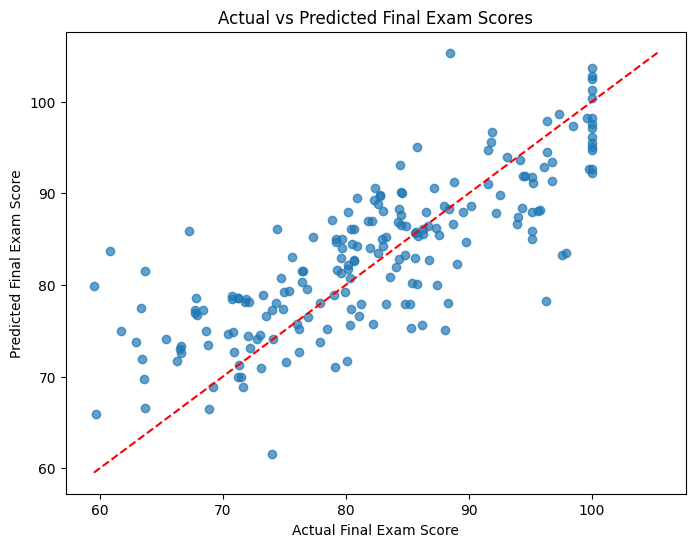

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(Y_test, y_pred_lr, alpha=0.7)

plt.xlabel("Actual Final Exam Score")
plt.ylabel("Predicted Final Exam Score")
plt.title("Actual vs Predicted Final Exam Scores")

# Perfect prediction reference line
min_value = min(Y_test.min(), y_pred_lr.min())
max_value = max(Y_test.max(), y_pred_lr.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    'r--'
)

plt.show()

The Actual vs Predicted plot demonstrates a strong positive relationship between predicted and actual final exam scores. Most predictions are distributed near the ideal diagonal line, indicating reasonable predictive accuracy. Some deviations are present, particularly at lower and higher score ranges, suggesting opportunities for further feature engineering or model improvement.

### Residual Plot

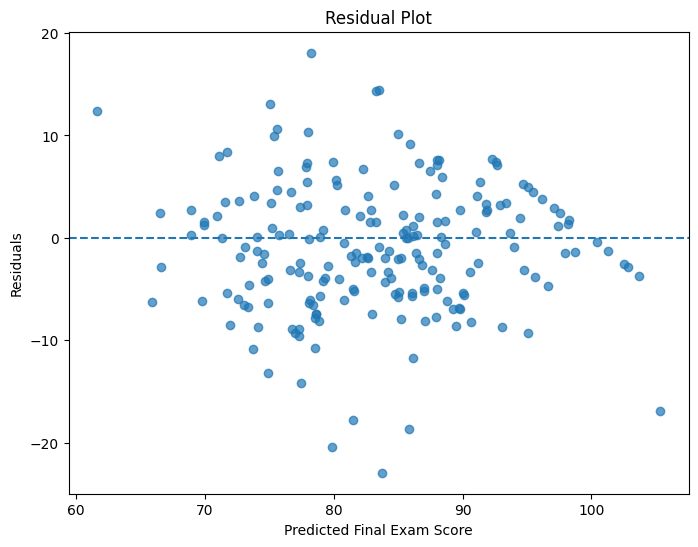

In [32]:
residuals = Y_test - y_pred_lr

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_lr, residuals, alpha=0.7)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Final Exam Score")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

The residual plot shows that prediction errors are generally distributed around zero, indicating no severe systematic bias. However, some clustering and variation in residuals suggest that the relationship between features and final exam scores may contain nonlinear patterns not fully captured by Linear Regression.

# Feature Coefficient Analysis

Since Linear Regression is your best model, we can inspect its coefficients to understand which features influence the predicted final exam score.

In [33]:
feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print("Number of coefficients:", len(lr_model.coef_))

Number of transformed features: 24
Number of coefficients: 24


In [34]:
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})

In [35]:
coefficients['Absolute_Coefficient'] = coefficients[
    'Coefficient'
].abs()

feature_importance_lr = coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

feature_importance_lr

,Feature,Coefficient,Absolute_Coefficient
16,num__study_time_hours,5.551605,5.551605
19,num__previous_grade,4.378573,4.378573
7,cat__internet_access_No,-2.979310,2.979310
8,cat__internet_access_Yes,2.979310,2.979310
17,num__attendance_percent,2.625828,2.625828
11,cat__part_time_job_No,1.677057,1.677057
12,cat__part_time_job_Yes,-1.677057,1.677057
23,num__engagement_score,1.413761,1.413761
18,num__sleep_hours,1.084839,1.084839
13,cat__attendance_risk_level_Critical,-0.953890,0.953890


During feature analysis, academic_level was identified as a potential data leakage feature because it was derived from the final exam score. The feature was removed to prevent target information from influencing predictions. Although model performance decreased slightly, the resulting evaluation provides a more realistic measure of generalization performance.

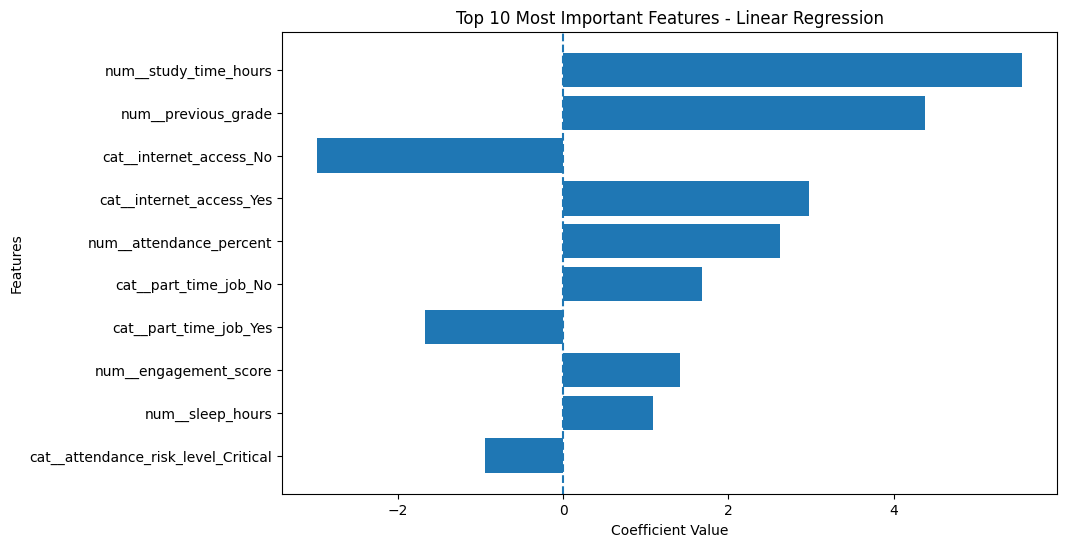

In [36]:
import matplotlib.pyplot as plt

top_features = feature_importance_lr.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features - Linear Regression")

plt.axvline(x=0, linestyle='--')

plt.gca().invert_yaxis()

plt.show()

# Upgrade to MAPIE

## 1. Create the Base Model Pipeline

In [37]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

## 2. Split Training Data for Conformal Prediction

In [38]:
X_train_model, X_calib, y_train_model, y_calib = train_test_split(
    X_train,
    Y_train,
    test_size=0.25,
    random_state=42
)

## 3. Train MAPIE

In [39]:
mapie_model = SplitConformalRegressor(
    estimator=lr_pipeline,
    confidence_level=0.95,
    prefit=False            # <--- Tells MAPIE it is safe to run .fit()
)

mapie_model.fit(
    X_train_model,
    y_train_model
)

In [40]:
mapie_model.conformalize(
    X_calib,
    y_calib
)

## 4. Make Predictions with Prediction Intervals

In [41]:
y_pred, y_intervals = mapie_model.predict_interval(X_test)

## 5. Display Predictions

In [42]:
prediction_results = pd.DataFrame({
    'Actual Score': Y_test.values,
    'Predicted Score': y_pred,
    'Lower Bound': y_intervals[:, 0, 0],
    'Upper Bound': y_intervals[:, 1, 0]
})

prediction_results.head(10)

,Actual Score,Predicted Score,Lower Bound,Upper Bound
0,71.8,77.222152,65.253210,89.191095
1,66.6,72.800445,60.831502,84.769387
2,62.9,73.506143,61.537200,85.475085
3,95.2,91.146430,79.177488,103.115373
4,90.2,88.763568,76.794626,100.732511
5,63.6,69.606523,57.637580,81.575465
6,96.8,93.128037,81.159095,105.096980
7,77.9,74.229046,62.260103,86.197988
8,66.5,71.870500,59.901557,83.839442
9,59.7,64.828428,52.859485,76.797370


## 6. Evaluate Interval Coverage

In [43]:
lower_bounds = y_intervals[:, 0, 0]
upper_bounds = y_intervals[:, 1, 0]

coverage = (
    (Y_test.values >= lower_bounds) &
    (Y_test.values <= upper_bounds)
).mean()

print(f"Prediction Interval Coverage: {coverage:.2%}")

Prediction Interval Coverage: 94.50%


Visualize MAPIE Prediction Intervals

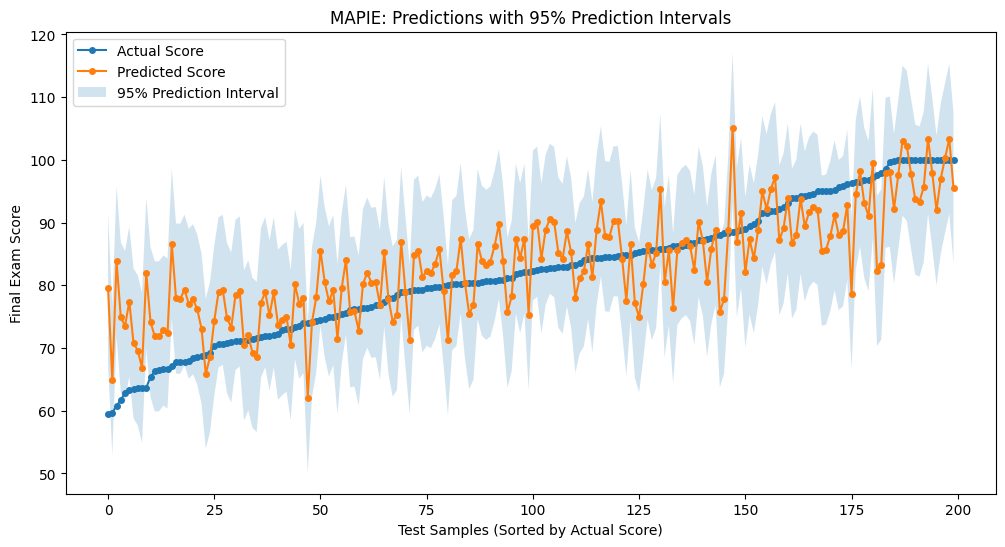

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by actual score for cleaner visualization
sorted_idx = np.argsort(Y_test.values)

actual_sorted = Y_test.values[sorted_idx]
predicted_sorted = y_pred[sorted_idx]
lower_sorted = lower_bounds[sorted_idx]
upper_sorted = upper_bounds[sorted_idx]

plt.figure(figsize=(12, 6))

plt.plot(
    actual_sorted,
    label='Actual Score',
    marker='o',
    markersize=4
)

plt.plot(
    predicted_sorted,
    label='Predicted Score',
    marker='o',
    markersize=4
)

plt.fill_between(
    range(len(actual_sorted)),
    lower_sorted,
    upper_sorted,
    alpha=0.2,
    label='95% Prediction Interval'
)

plt.xlabel("Test Samples (Sorted by Actual Score)")
plt.ylabel("Final Exam Score")
plt.title("MAPIE: Predictions with 95% Prediction Intervals")

plt.legend()
plt.show()